<a href="https://colab.research.google.com/github/ArshAnan/ArshAnan/blob/main/notebooks/03_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/ArshAnan/llm-offload-controller.git
%cd llm-offload-controller

!git config user.email "arshanand2524@gmail.com"
!git config user.name "ArshAnan"

Mounted at /content/drive
Cloning into 'llm-offload-controller'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 63 (delta 27), reused 5 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 96.52 KiB | 1.86 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/llm-offload-controller


In [2]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

# Load preprocessed training data from Drive
drive_path = "/content/drive/MyDrive/llm-offload-controller/data/"
train_df = pd.read_csv(drive_path + "train_processed.csv")
test_df  = pd.read_csv(drive_path + "test_processed.csv")

print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Train: 8,301,611 rows
Test:  2,075,403 rows


In [5]:
state_cols = [
    'req_tokens_norm',
    'rolling_req_tokens',
    'inter_arrival_norm',
    'rolling_inter_arrival',
    'arrival_rate_norm',
    'hour_of_day',
    'is_gpt4',
    'is_large_request'
]

class OffloadEnv(gym.Env):
    def __init__(self, df, state_cols):
        super().__init__()

        self.state_cols = state_cols
        self.current_step = 0

        # Convert to numpy arrays upfront for fast lookup
        self.states = df[state_cols].values.astype(np.float32)
        self.req_tokens = df['req_tokens'].values
        self.rolling_req_tokens = df['rolling_req_tokens'].values
        self.is_large_request = df['is_large_request'].values
        self.n_steps = len(df)

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0,
            shape=(len(state_cols),),
            dtype=np.float32
        )

    def reset(self, seed=None):
        self.current_step = 0
        return self.states[0], {}

    def step(self, action):
        energy_cost = [1.0, 2.5, 6.0]
        latency_cost = [0.001, 0.0005, 0.0002]

        req_tokens = self.req_tokens[self.current_step]
        queue_pressure = self.rolling_req_tokens[self.current_step] * self.is_large_request[self.current_step]

        if action == 0:
            estimated_latency = latency_cost[0] * req_tokens * (1 + queue_pressure * 10)
        else:
            estimated_latency = latency_cost[action] * req_tokens

        p99_target = 2991
        alpha = 1.0
        beta  = 0.1

        if estimated_latency > p99_target:
            reward = -alpha * (estimated_latency - p99_target) - beta * energy_cost[action]
        else:
            reward = -beta * energy_cost[action]

        self.current_step += 1
        done = self.current_step >= self.n_steps - 1
        next_obs = self.states[self.current_step]

        return next_obs, reward, done, False, {}

print("Environment redefined with numpy backend")

Environment redefined with numpy backend


In [6]:
# Quick test — how long does one step take?
import time

env = OffloadEnv(train_df, state_cols)
obs, _ = env.reset()

start = time.time()
for i in range(100):
    action = 0
    obs, reward, done, _, _ = env.step(action)
end = time.time()

print(f"100 steps took: {end - start:.3f} seconds")
print(f"Estimated time for 10k steps: {(end - start) * 100:.1f} seconds")

100 steps took: 0.001 seconds
Estimated time for 10k steps: 0.1 seconds


In [8]:
def run_baseline(env, policy, n_steps=10000):
    obs, _ = env.reset()
    total_reward = 0
    rewards = []
    actions = []

    for _ in range(n_steps):
        action = policy(obs)
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        rewards.append(reward)
        actions.append(action)
        if done:
            break

    return {
        'total_reward': total_reward,
        'mean_reward': np.mean(rewards),
        'actions': actions
    }

# Baseline 1 — always local
always_local = lambda obs: 0

print("run_baseline defined")

run_baseline defined


In [9]:
env = OffloadEnv(train_df, state_cols)
results_local = run_baseline(env, always_local)
print(f"Always Local | Mean Reward: {results_local['mean_reward']:.4f} | Total: {results_local['total_reward']:.2f}")

Always Local | Mean Reward: -0.1000 | Total: -1000.00


In [10]:
# Baseline 2 — random policy
random_policy = lambda obs: env.action_space.sample()

env = OffloadEnv(train_df, state_cols)
results_random = run_baseline(env, random_policy)
print(f"Random Policy | Mean Reward: {results_random['mean_reward']:.4f} | Total: {results_random['total_reward']:.2f}")

Random Policy | Mean Reward: -0.3173 | Total: -3172.80


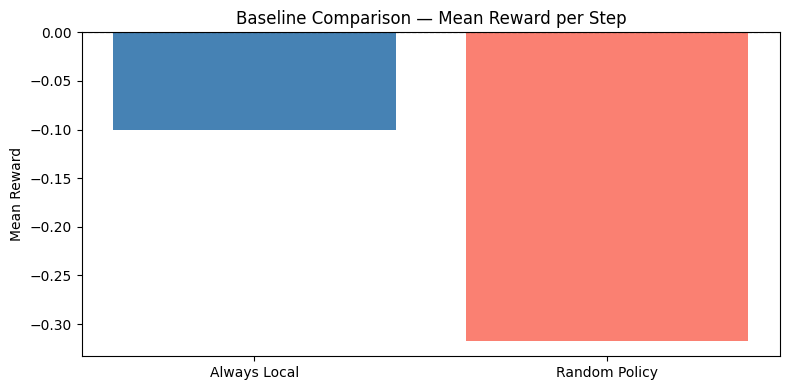

In [12]:
import os
import matplotlib.pyplot as plt

baselines = ['Always Local', 'Random Policy']
scores = [results_local['mean_reward'], results_random['mean_reward']]

plt.figure(figsize=(8, 4))
plt.bar(baselines, scores, color=['steelblue', 'salmon'])
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Baseline Comparison — Mean Reward per Step")
plt.ylabel("Mean Reward")
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/baseline_comparison.png", dpi=150)
plt.show()